In [ ]:
from google.colab import files
uploaded = files.upload()


Saving weatherHistory.csv to weatherHistory.csv


In [ ]:
import os
print(os.listdir())

['.config', 'weatherHistory.csv', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dropout, GlobalAveragePooling1D

In [ ]:
df = pd.read_csv("weatherHistory.csv")

df = df[['Formatted Date', 'Temperature (C)', 'Humidity', 'Wind Speed (km/h)']]
df.columns = ['Date', 'Temp', 'Humidity', 'WindSpeed']

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

print(df.head())

                           Date      Temp  Humidity  WindSpeed
2880  2006-01-01 00:00:00+01:00  0.577778      0.89    17.1143
2881  2006-01-01 01:00:00+01:00  1.161111      0.85    16.6152
2882  2006-01-01 02:00:00+01:00  1.666667      0.82    20.2538
2883  2006-01-01 03:00:00+01:00  1.711111      0.82    14.4900
2884  2006-01-01 04:00:00+01:00  1.183333      0.86    13.9426


/tmp/ipykernel_6647/303638657.py:6: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(df[['Temp', 'Humidity', 'WindSpeed']])

In [ ]:
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])  # predict Temp
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled)

# Train-Test Split
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
lstm_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(50),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

history_lstm = lstm_model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 0.0028
Epoch 2/5
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5.8226e-04
Epoch 3/5
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 4.6729e-04
Epoch 4/5
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 4.4081e-04
Epoch 5/5
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 4.2880e-04


In [ ]:
pred_lstm = lstm_model.predict(X_test)

603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [ ]:
#transformer model
def build_transformer(input_shape):
    inputs = Input(shape=input_shape)

    x = MultiHeadAttention(num_heads=2, key_dim=32)(inputs, inputs)
    x = LayerNormalization()(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.1)(x)

    x = GlobalAveragePooling1D()(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')

    return model

transformer = build_transformer((X_train.shape[1], X_train.shape[2]))

In [ ]:
#train
history_trans = transformer.fit(X_train, y_train, epochs=5, batch_size=32)

#predictions
pred_trans = transformer.predict(X_test)

Epoch 1/5
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0059
Epoch 2/5
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.0043
Epoch 3/5
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.0042
Epoch 4/5
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.0041
Epoch 5/5
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.0040
603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
#physics
def physics_smoothing(pred):
    pred = pred.copy()
    for i in range(1, len(pred)):
        if abs(pred[i] - pred[i-1]) > 5:
            pred[i] = (pred[i] + pred[i-1]) / 2
    return pred

pred_lstm = physics_smoothing(pred_lstm)
pred_trans = physics_smoothing(pred_trans)

In [ ]:
#evaluation
rmse_lstm = np.sqrt(mean_squared_error(y_test, pred_lstm))
rmse_trans = np.sqrt(mean_squared_error(y_test, pred_trans))

mae_lstm = mean_absolute_error(y_test, pred_lstm)
mae_trans = mean_absolute_error(y_test, pred_trans)

print("LSTM RMSE:", rmse_lstm)
print("Transformer RMSE:", rmse_trans)

print("LSTM MAE:", mae_lstm)
print("Transformer MAE:", mae_trans)

LSTM RMSE: 0.01540421392451243
Transformer RMSE: 0.0606432232036794
LSTM MAE: 0.011127160199318906
Transformer MAE: 0.04916999371917414


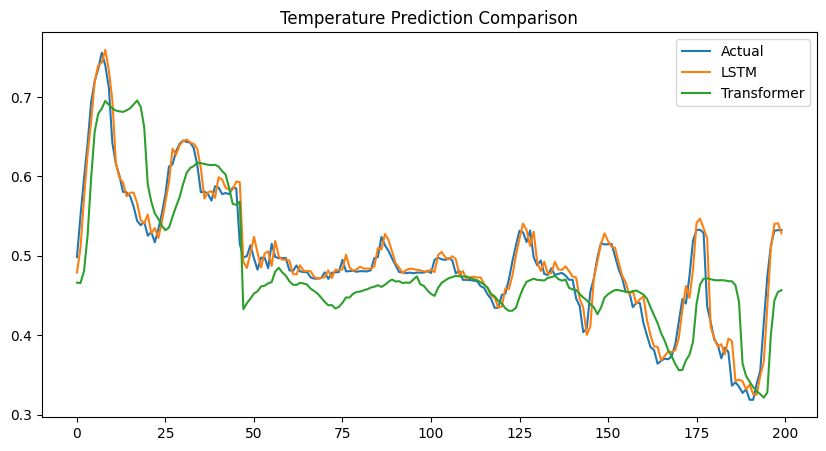

In [ ]:
#plot
plt.figure(figsize=(10,5))

plt.plot(y_test[:200], label="Actual")
plt.plot(pred_lstm[:200], label="LSTM")
plt.plot(pred_trans[:200], label="Transformer")

plt.legend()
plt.title("Temperature Prediction Comparison")
plt.show()

In [ ]:
#heat risk o/p
def heat_risk(temp):
    if temp > 0.7:
        return "High"
    elif temp > 0.5:
        return "Medium"
    else:
        return "Low"

print("Final Prediction (Transformer):", pred_trans[-1][0])
print("Heat Risk:", heat_risk(pred_trans[-1][0]))

Final Prediction (Transformer): 0.35027426
Heat Risk: Low
